In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Null Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.0000

In [5]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


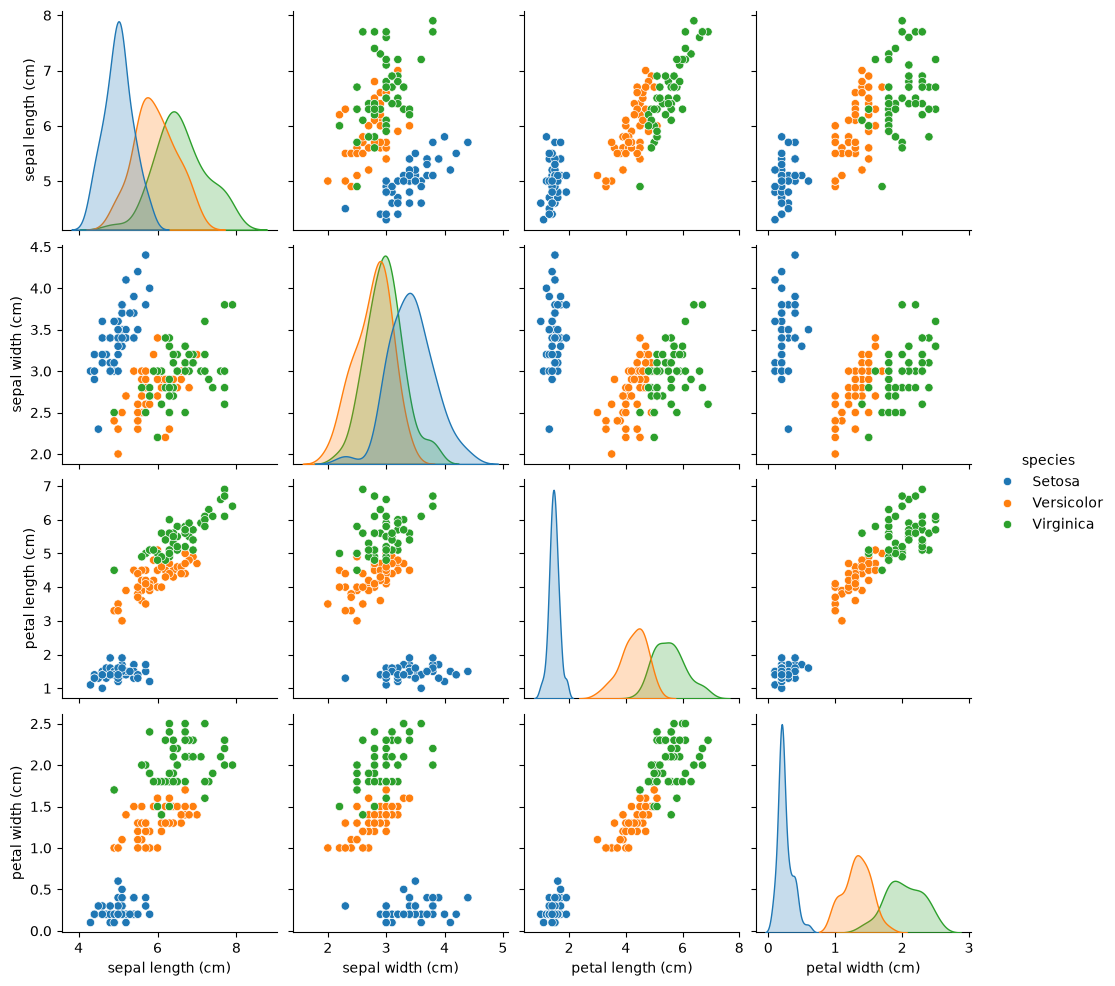

In [6]:
sns.pairplot(df, hue="species")
plt.show()

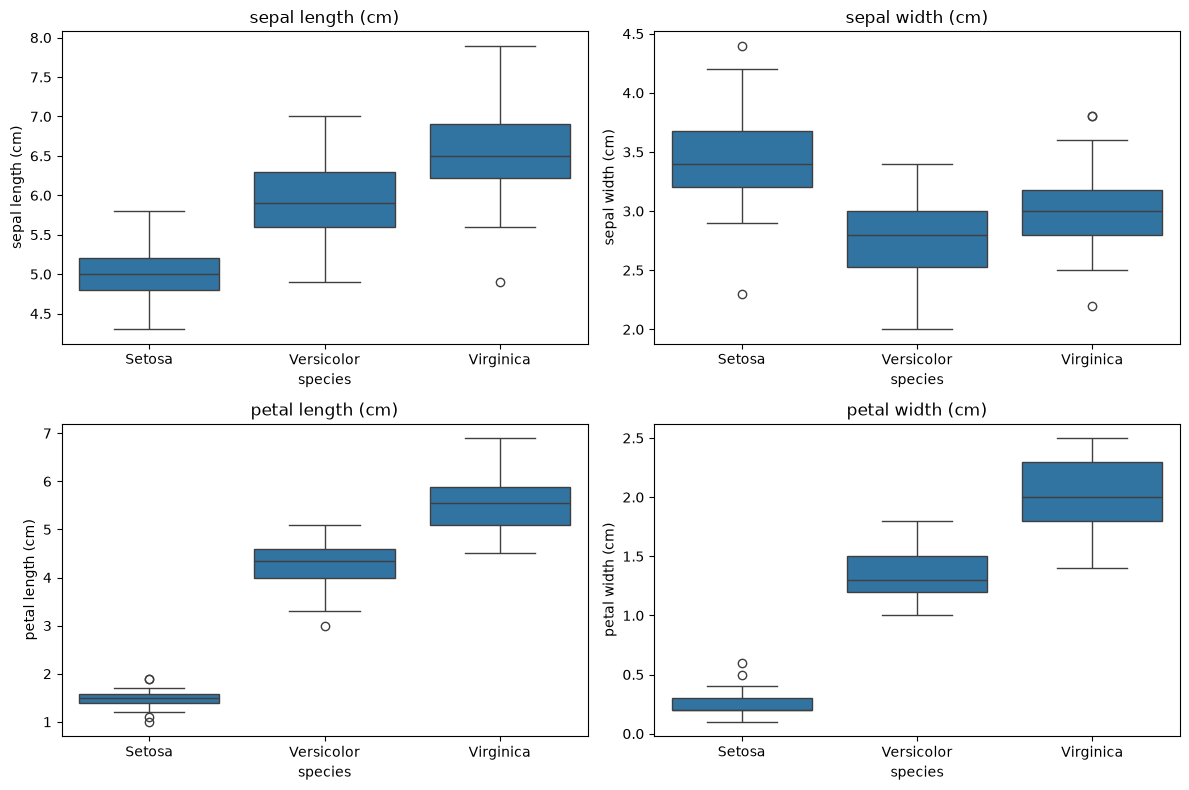

In [7]:
plt.figure(figsize=(12, 8))

features = iris.feature_names

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

### Feature Selection

Petal length and petal width are the most discriminative features because they show clearer differences between the three Iris species. Sepal length and sepal width are useful but provide comparatively less separation.

In [8]:
X = df[iris.feature_names]
y = iris.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [10]:
model1 = LogisticRegression(max_iter=200)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred1))

print("\nClassification Report:")
print(classification_report(
    y_test,
    pred1,
    target_names=iris.target_names
))

Logistic Regression Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [11]:
model2 = KNeighborsClassifier(n_neighbors=5)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, pred2))

print("\nClassification Report:")
print(classification_report(
    y_test,
    pred2,
    target_names=iris.target_names
))

KNN Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



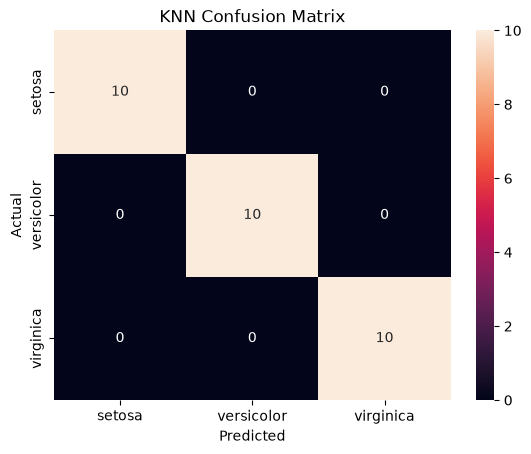

In [12]:
cm = confusion_matrix(y_test, pred2)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [13]:
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

if acc1 > acc2:
    print("Best Model: Logistic Regression")
    print("Accuracy:", acc1)
else:
    print("Best Model: KNN")
    print("Accuracy:", acc2)

Best Model: KNN
Accuracy: 1.0


### Conclusion

Two classification models, Logistic Regression and K-Nearest Neighbours, were trained to classify Iris flower species. Both models were evaluated using accuracy, precision, recall, F1-score and confusion matrix. The model with the highest accuracy was selected as the best-performing model. Petal length and petal width were the most discriminative features.